come here after random_first.ipynb 


### Bagging vs Random forest. 


> we will look how random forest pefrom better? 

- we should know that random forest is type of algorithm which help us achieve low bias and low variance model in ML. 

ususally you would get a low bias but high variance model like D.T , KNN ,svm etc 
or
high bias low variance model like logistic . 


how random forest help achieve it then ? 

- You know random forest is a bagging techniuqe . so we randomly select sample i.e we bootstrap them . 

now say we had 10k data and we had 3 decision tree model as our baseline model in ensemble . 

we provide randomly 500 data with replacement to each model . and train them .. 
- remeber the model is still lowe bias high variance even after trained. 


```  Remember, high bias means algo/model cant even capture the patterns of data during traning phase , peforms poorly at traning phase  and High variance means like we trained a mdoel on a data and say if we change the data little then also its accuracy or ouput varies max, changes in a large way. the model learn pattern data so closely that even small change in trainign data can cause significant change and cause overfitting ```


> bias and variance inversely proportional 


and D.t overfits meanig its low bias and high variance model .. 

```
now what we do is in the 10k data we randomly change 100 poinsta and provide randomlyl models 500 data so doing this some model recive about 50 data changed in 500 data used to train , some might get 10 changed some might get none changed .. 

doing this the changing impact hasnt to be beard by a single model so the data dosent really changes and doesnet cause variability so model becomes low variance .. D.t so it is alredy low bias doing this it also became low variance..  ```


## Bagging vs Random Forest.

- previously we said we are doing Random Forest, its collection of D.T so we made an ensemble, kept D.T as baseline model, trained them and did voting count.
> Did doing this make it a Random Forest ?? NOOO..

```text
There are some significant differences,

- firstly, in Bagging we can use any model, i.e. the baseline model used should be same but we can use any model like D.T, KNN, SVM, Logistic Regression etc. Its just that if we took SVM then all the models in the ensemble should be SVM.

- THE most significant difference is that,

Say we used D.T in Bagging. Then each Decision Tree is trained on a different bootstrap sampled dataset (row sampling), but while creating the tree, at every split it checks ALL the features and chooses the best one using Information Gain/Gini. It keeps doing this until the tree is built.

Whereas, in Random Forest, before every split, a random subset of features is selected. For example, if we have 5 columns, at the root node it may randomly select columns 2 and 5, then choose the best split only from those two. At the next node it may randomly select columns 1 and 4, then again find the best split only from those. This random feature selection happens at EVERY node and is the major difference between Bagging and Random Forest.
```

In [3]:
import pandas as pd 
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
import numpy as np 

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)
     

df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.662565,1.520386,-2.005517,-0.358548,0.567946,0
1,-1.711573,0.914415,-0.874185,2.457750,0.720854,1
2,0.103462,2.336111,-2.431592,-1.644524,0.852654,0
3,-1.307413,0.521174,0.368594,0.999356,1.507118,1
4,-3.318672,-0.668812,0.045962,-1.967417,2.101511,1


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [5]:
# lets see how decsion tree does the split first 

dt=DecisionTreeClassifier()
dt.fit(X_train, y_train)
ypred=dt.predict(X_test)
accuracy_score(ypred,y_test)

0.9393939393939394

[Text(0.5, 0.875, 'x[2] <= -0.295\ngini = 0.499\nsamples = 67\nvalue = [32, 35]'),
 Text(0.25, 0.625, 'x[0] <= -1.587\ngini = 0.301\nsamples = 38\nvalue = [31, 7]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.375, 0.375, 'x[3] <= 1.934\ngini = 0.061\nsamples = 32\nvalue = [31, 1]'),
 Text(0.25, 0.125, 'gini = 0.0\nsamples = 31\nvalue = [31, 0]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.75, 0.625, 'x[1] <= -1.101\ngini = 0.067\nsamples = 29\nvalue = [1, 28]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.875, 0.375, 'gini = 0.0\nsamples = 28\nvalue = [0, 28]')]

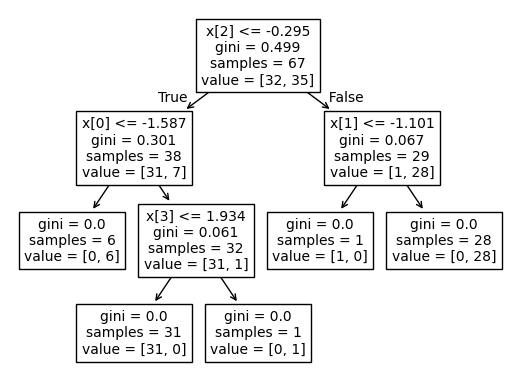

In [7]:
plot_tree(dt)

so dt used first col2 then splitted into col 0 and col  1 then again o splitted to col 3....

In [12]:
# bagging 

bag=BaggingClassifier(estimator=DecisionTreeClassifier(),bootstrap=True,max_features=2 ,n_estimators=5) # took 5 model 

bag.fit(df.iloc[:,:5],df.iloc[:,-1])
bagpred=bag.predict(X_test)

''' here we will take 2 columns, now in bagging each split will happen form this 2 selected col '''


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names
  warnings.warn(


' here we will take 2 columns, now in bagging each split will happen form this 2 selected col '

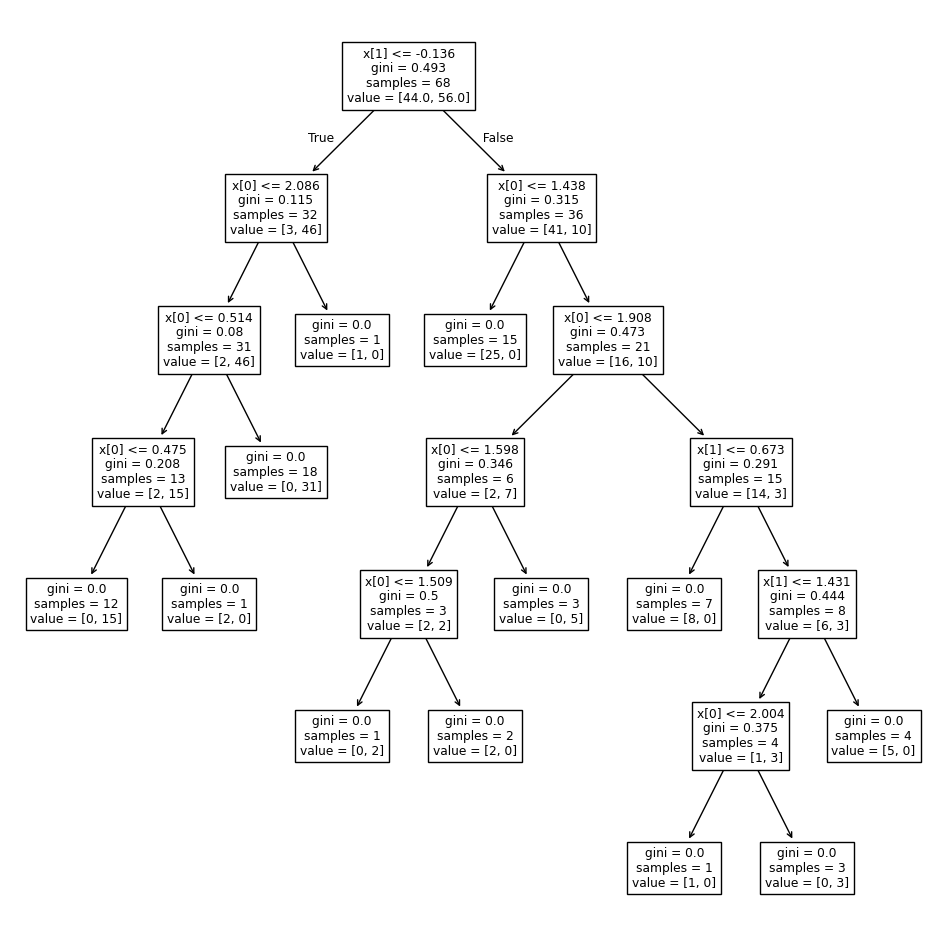

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,12))
plot_tree(bag.estimators_[4]) # out of 5 we plotted first trained model 
plt.show()

Here we are telling BaggingClassifier to randomly choose only 2 features for each Decision Tree using max_features=2. Therefore this entire tree will use only these two columns while building itself.

In [ ]:
# lets see feature t used  by diffrent 5 models in bagging 
bag.estimators_features_

[array([1, 3]), array([1, 4]), array([0, 3]), array([3, 4]), array([1, 0])]

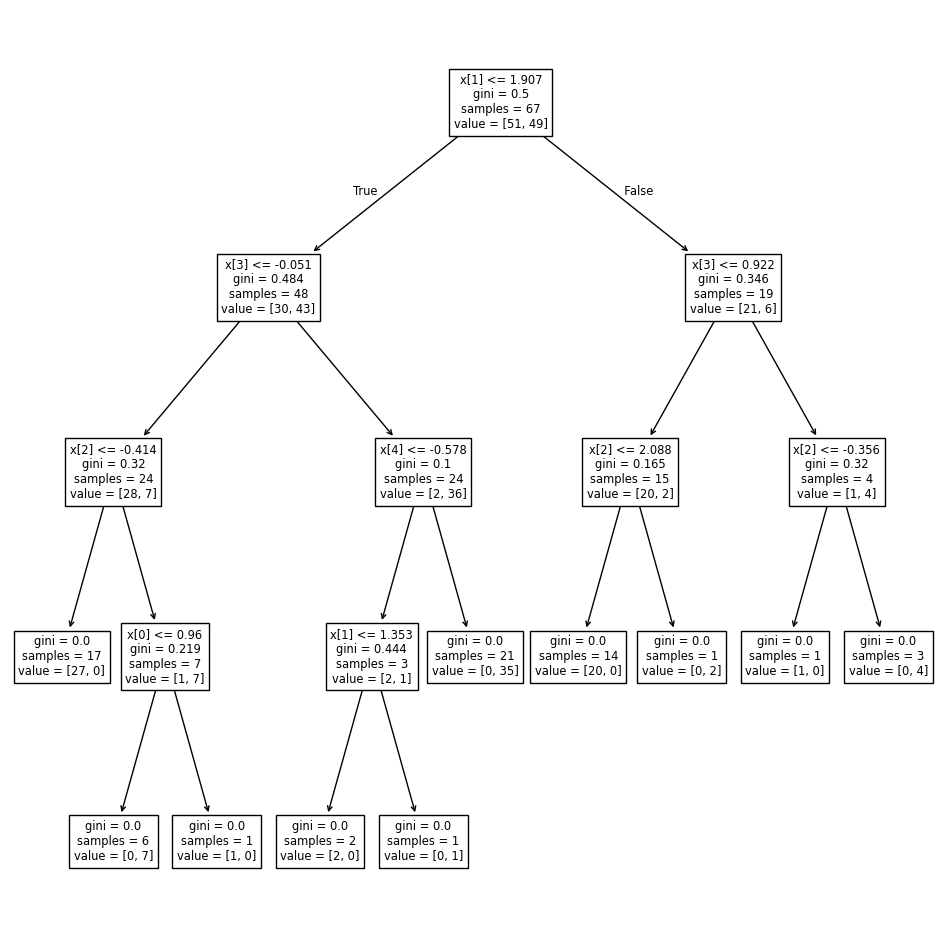

In [25]:
# lets see random forest 

rf=RandomForestClassifier(max_features=2)
rf.fit(df.iloc[:,:5],df.iloc[:,-1]) # featuer and target provided 

import matplotlib.pyplot as plt
plt.figure(figsize=(12,12))
plot_tree(rf.estimators_[0]) # out of 5 we plotted first trained model 
plt.show()

x0 x3 x2 it is randomly selecting features at each node level split 

In [27]:
repred=rf.predict(X_test)
accuracy_score(y_test,repred)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


1.0

In [26]:
bagpred=bag.predict(X_test)
accuracy_score(y_test,bagpred)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names
  warnings.warn(


0.9696969696969697